# 05 – Cluster Profiling and Temporal Stability Analysis

This notebook analyzes the clusters produced by the final KMeans segmentation model.

The goal is to interpret customer segments, evaluate cluster stability across time periods, and identify behavioral changes between training and validation datasets.

Key objectives:

• Profile each cluster using customer-level features  
• Assign meaningful business interpretations to segments  
• Compare cluster distributions across time windows  
• Evaluate temporal stability of the segmentation framework

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### Load Clustered Datasets

In [2]:
train_df = pd.read_csv("../data/processed/train_clustered.csv")
valid_df = pd.read_csv("../data/processed/valid_clustered.csv")

print("Train dataset shape:", train_df.shape)
print("Validation dataset shape:", valid_df.shape)

train_df.head()

Train dataset shape: (4266, 14)
Validation dataset shape: (4297, 14)


,Customer ID,first_purchase,last_purchase,frequency,monetary,recency,lifespan,avg_order_value,active_months,avg_purchase_gap,spending_volatility,avg_basket_size,revenue_contribution,cluster
0,12346,2009-12-14 08:34:00,2010-06-28 13:53:00,11,372.86,156,196,33.90,4,19.20,37.30,6.36,0.00,2
1,12347,2010-10-31 14:20:00,2010-10-31 14:20:00,1,611.53,31,0,611.53,1,0.00,0.00,509.00,0.00,0
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,1,222.16,65,0,222.16,1,0.00,0.00,373.00,0.00,0
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,"2,671.14",34,181,890.38,3,90.00,620.79,331.00,0.00,4
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,2,0,300.93,1,0.00,0.00,261.00,0.00,0


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4266 entries, 0 to 4265
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer ID           4266 non-null   int64  
 1   first_purchase        4266 non-null   object 
 2   last_purchase         4266 non-null   object 
 3   frequency             4266 non-null   int64  
 4   monetary              4266 non-null   float64
 5   recency               4266 non-null   int64  
 6   lifespan              4266 non-null   int64  
 7   avg_order_value       4266 non-null   float64
 8   active_months         4266 non-null   int64  
 9   avg_purchase_gap      4266 non-null   float64
 10  spending_volatility   4266 non-null   float64
 11  avg_basket_size       4266 non-null   float64
 12  revenue_contribution  4266 non-null   float64
 13  cluster               4266 non-null   int64  
dtypes: float64(6), int64(6), object(2)
memory usage: 466.7+ KB


## Cluster Size Distribution

Before interpreting clusters, we first examine the distribution of customers across segments in both the training and validation datasets.

This helps assess whether the segmentation structure remains stable across time periods.

### Train Cluster Distribution

In [4]:
train_cluster_dist = train_df["cluster"].value_counts(normalize=True).sort_index() * 100
train_cluster_dist

cluster
0   20.72
1   18.54
2   27.33
3   15.12
4   18.28
Name: proportion, dtype: float64

### Validation Cluster Distribution

In [5]:
valid_cluster_dist = valid_df["cluster"].value_counts(normalize=True).sort_index() * 100
valid_cluster_dist

cluster
0   23.16
1   17.69
2   26.48
3   14.71
4   17.97
Name: proportion, dtype: float64

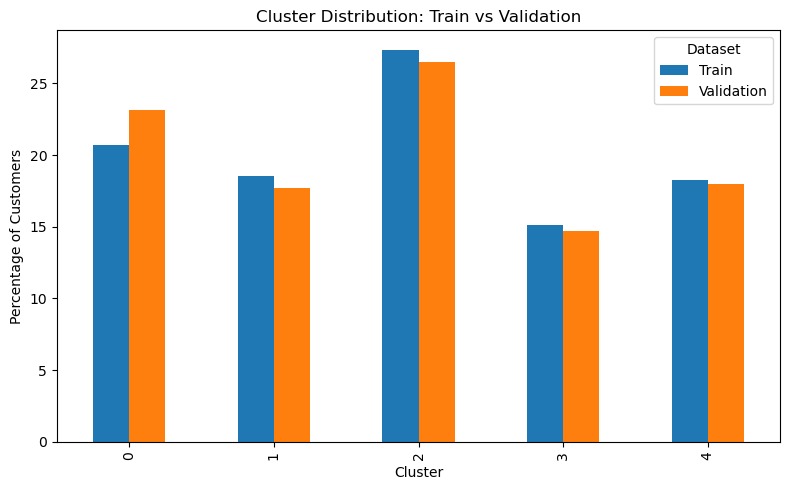

In [6]:
cluster_dist = pd.DataFrame({
    "Train": train_cluster_dist,
    "Validation": valid_cluster_dist
})

ax = cluster_dist.plot(kind="bar", figsize=(8,5))

plt.ylabel("Percentage of Customers")
plt.xlabel("Cluster")
plt.title("Cluster Distribution: Train vs Validation")

plt.legend(title="Dataset")
plt.tight_layout()

plt.show()

## Preliminary Observation: Cluster Distribution

The distribution of customers across clusters remains relatively stable between the training and validation periods.

Cluster 2 continues to represent the largest segment in both datasets, while Cluster 3 remains the smallest. A slight increase is observed in Cluster 0 within the validation dataset, while other clusters show minor decreases.

Overall, the segmentation structure appears reasonably consistent across time, suggesting that the clustering model captures stable behavioral patterns.

## Cluster Feature Profiling

To interpret the behavioral characteristics of each segment, we compute the average feature values per cluster.

This analysis helps identify the defining patterns of each customer group and enables meaningful business interpretation of the segmentation results.

### Define Profiling Columns

In [7]:
profile_cols = ["recency","frequency","monetary","lifespan","avg_order_value","avg_purchase_gap","spending_volatility", "avg_basket_size","active_months","revenue_contribution"]

### Compute Cluster Profile Table

In [8]:
cluster_profile = train_df.groupby("cluster")[profile_cols].mean().round(2)

cluster_profile

,recency,frequency,monetary,lifespan,avg_order_value,avg_purchase_gap,spending_volatility,avg_basket_size,active_months,revenue_contribution
cluster,,,,,,,,,,
0,130.58,1.03,496.83,0.06,477.62,0.05,4.50,291.03,1.00,0.00
1,15.48,12.81,"6,584.96",305.38,409.77,41.72,264.87,237.16,6.93,0.00
2,73.60,3.19,655.90,153.21,215.22,88.68,95.35,114.47,2.64,0.00
3,167.04,1.16,143.86,3.47,129.96,2.91,6.88,60.07,1.05,0.00
4,70.65,3.76,"2,541.16",171.11,690.55,78.37,377.99,614.91,3.10,0.00


In [16]:
cluster_revenue = train_df.groupby("cluster")["monetary"].sum()
total_revenue = train_df["monetary"].sum()

cluster_profile["revenue_share_%"] = (cluster_revenue / total_revenue) * 100

cluster_profile = cluster_profile.round(2)

cluster_profile

,recency,frequency,monetary,lifespan,avg_order_value,avg_purchase_gap,spending_volatility,avg_basket_size,active_months,revenue_contribution,revenue_share_%
cluster,,,,,,,,,,,
0,130.58,1.03,496.83,0.06,477.62,0.05,4.50,291.03,1.00,0.00,5.17
1,15.48,12.81,"6,584.96",305.38,409.77,41.72,264.87,237.16,6.93,0.00,61.37
2,73.60,3.19,655.90,153.21,215.22,88.68,95.35,114.47,2.64,0.00,9.01
3,167.04,1.16,143.86,3.47,129.96,2.91,6.88,60.07,1.05,0.00,1.09
4,70.65,3.76,"2,541.16",171.11,690.55,78.37,377.99,614.91,3.10,0.00,23.35


### Cluster Interpretation

The cluster profiling results reveal five distinct customer segments based on purchasing behavior. 
Each cluster demonstrates unique characteristics in terms of recency, purchase frequency, spending level, and purchasing patterns.

**Cluster 0 – Recent One-Time Buyers**

Customers in this segment typically made a single purchase relatively recently but have not yet developed repeat buying behavior. 
Their purchase frequency and monetary value are low, and their customer lifespan is short. These customers represent potential new customers who may convert into regular buyers with effective retention strategies.

**Cluster 1 – VIP / Loyal Customers**

This segment represents the most valuable customers in the dataset. They have the highest purchase frequency, the largest total spending (monetary value), and the longest customer lifespan. 
These customers also contribute the largest share of total revenue. Maintaining strong engagement with this segment is critical, as they form the core revenue base of the business.

**Cluster 2 – Regular Mid-Value Customers**

Customers in this group show moderate purchase frequency and balanced spending behavior. Their recency values indicate reasonably active purchasing patterns, and their customer lifespan suggests consistent engagement with the business. 
This segment represents stable, regular customers with potential to grow into higher-value segments.

**Cluster 3 – Dormant Customers**

Customers in this cluster have the lowest engagement levels. They show long recency values, low purchase frequency, and minimal spending. 
These customers appear to be inactive or churned, indicating that they have not purchased for a long period. Re-activation campaigns may be required to win back this segment.

**Cluster 4 – High-Value Occasional Buyers**

Customers in this segment purchase less frequently but tend to place large orders when they do buy, reflected by their high average order value. 
Although they do not purchase regularly, their transactions contribute meaningful revenue, making them an important segment for targeted promotions and high-value product offerings.

## Temporal Stability Analysis

To evaluate the robustness of the segmentation framework, we analyze whether the behavioral characteristics of each cluster remain consistent across different time periods.

The clustering model was trained using the 2009–2010 dataset and then applied to the 2010–2011 dataset. By comparing cluster profiles between the training and validation datasets, we can assess whether the segmentation logic remains stable over time.

Stable behavioral patterns across time indicate that the clusters represent meaningful customer segments rather than artifacts of a specific dataset.

### Compute Validation Cluster Profiles

In [17]:
valid_cluster_profile = valid_df.groupby("cluster")[profile_cols].mean()

valid_cluster_revenue = valid_df.groupby("cluster")["monetary"].sum()
valid_total_revenue = valid_df["monetary"].sum()

valid_cluster_profile["revenue_share_%"] = (valid_cluster_revenue / valid_total_revenue) * 100

valid_cluster_profile = valid_cluster_profile.round(2)

valid_cluster_profile

,recency,frequency,monetary,lifespan,avg_order_value,avg_purchase_gap,spending_volatility,avg_basket_size,active_months,revenue_contribution,revenue_share_%
cluster,,,,,,,,,,,
0,132.61,1.03,492.84,0.10,484.56,0.10,3.19,309.04,1.00,0.00,5.86
1,14.90,12.74,"6,890.35",304.89,440.28,41.48,291.34,253.93,7.05,0.00,62.56
2,76.68,3.11,626.79,155.82,208.65,92.19,84.77,117.11,2.69,0.00,8.52
3,176.46,1.13,142.30,1.87,132.39,1.01,5.47,63.43,1.05,0.00,1.07
4,65.99,3.62,"2,383.11",164.92,746.06,77.14,349.91,483.16,3.06,0.00,21.98


### Temporal Stability Observation

The comparison between the training and validation cluster profiles indicates that the behavioral characteristics of the segments remain largely consistent across time periods.

Clusters that demonstrate high purchase frequency and strong monetary value in the training dataset continue to exhibit similar patterns in the validation dataset. Likewise, segments with low engagement maintain relatively low activity across both periods.

Although minor variations in feature values are observed, the overall structure of the clusters remains stable. The relative ordering of clusters in terms of recency, purchase frequency, and spending behavior remains largely unchanged.

This consistency suggests that the segmentation framework captures underlying customer behavior rather than patterns specific to a single dataset. Therefore, the clustering model demonstrates good temporal stability and can be considered reliable for analyzing customer segments over time.

## Customer Migration Analysis

### Check Customer Overlap

In [19]:
train_customers = set(train_df["Customer ID"])
valid_customers = set(valid_df["Customer ID"])

overlap_customers = train_customers.intersection(valid_customers)

print("Train customers:", len(train_customers))
print("Validation customers:", len(valid_customers))
print("Customers appearing in both periods:", len(overlap_customers))

Train customers: 4266
Validation customers: 4297
Customers appearing in both periods: 2713


### Create Overlap Dataset

In [20]:
train_overlap = train_df[train_df["Customer ID"].isin(overlap_customers)]
valid_overlap = valid_df[valid_df["Customer ID"].isin(overlap_customers)]

### Merge Train and Validation Clusters

In [22]:
migration_df = pd.merge(
    train_overlap[["Customer ID", "cluster"]],
    valid_overlap[["Customer ID", "cluster"]],
    on="Customer ID",
    suffixes=("_train", "_valid")
)

migration_df.head()

,Customer ID,cluster_train,cluster_valid
0,12346,2,4
1,12347,0,4
2,12348,0,4
3,12349,4,0
4,12352,2,1


### Migration Matrix

In [23]:
migration_matrix = pd.crosstab(
    migration_df["cluster_train"],
    migration_df["cluster_valid"]
)

migration_matrix

cluster_valid,0,1,2,3,4
cluster_train,,,,,
0,154,26,88,52,73
1,42,414,141,18,130
2,143,86,348,135,65
3,45,10,62,77,7
4,134,129,77,14,243


In [24]:
migration_matrix_pct = migration_matrix.div(
    migration_matrix.sum(axis=1),
    axis=0
) * 100

migration_matrix_pct.round(2)

cluster_valid,0,1,2,3,4
cluster_train,,,,,
0,39.19,6.62,22.39,13.23,18.58
1,5.64,55.57,18.93,2.42,17.45
2,18.40,11.07,44.79,17.37,8.37
3,22.39,4.98,30.85,38.31,3.48
4,22.45,21.61,12.90,2.35,40.70


### Visualize Migration

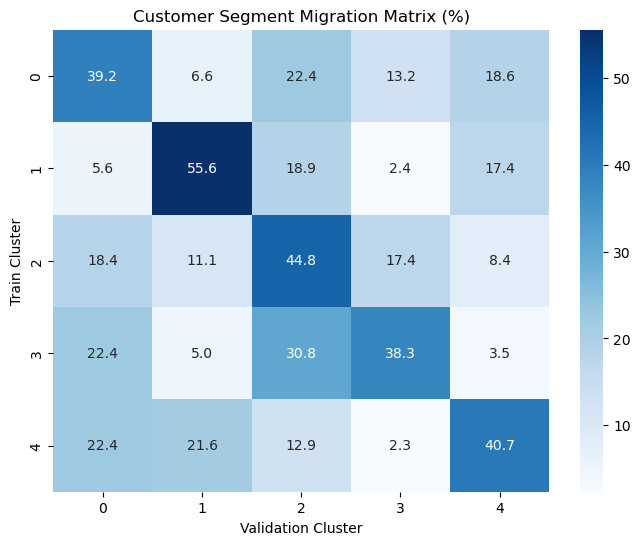

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(migration_matrix_pct, annot=True, fmt=".1f", cmap="Blues")

plt.title("Customer Segment Migration Matrix (%)")
plt.xlabel("Validation Cluster")
plt.ylabel("Train Cluster")

plt.show()